In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
df = pd.read_csv("../content/placement_predict_50k Dataset (1).csv")

In [ ]:
df.columns


Index(['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream',
       'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1',
       'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6',
       'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships',
       'Projects', 'Workshops', 'Certifications', 'Publications',
       'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore',
       'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus',
       'IsAnomaly'],
      dtype='object')

In [ ]:
import numpy as np

target_col = 'CGPA'
drop_cols = [target_col, "StudentID", "CGPA_Tier"]

feature_df = df.drop(columns=drop_cols).select_dtypes(include=[np.number])
feature_df = feature_df.fillna(feature_df.mean())

x = feature_df.values
y = df[target_col].values.reshape(-1, 1)


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
scalar = StandardScaler()
x_train = scalar.fit_transform(x_train)
x_test = scalar.transform(x_test)

In [ ]:
x_train_b = np.c_[np.ones((x_train.shape[0],1)),x_train]
x_test_b = np.c_[np.ones((x_test.shape[0],1)),x_test]

In [ ]:
def gradient_descent(x, y, lr=0.01, n_iters=1000):
  m, n = x.shape
  theta = np.zeros((n,1))
  losses = []

  for i in range(n_iters):
    y_pred = x @ theta
    error = y_pred - y

    loss = (1/(2*m)) * np.sum(error**2)
    losses.append(loss)

    gradient = (1/m) * (x.T @ error)
    theta -= lr * gradient

    if i % 100 == 0:
      print(f"Iteration {i:4d}: Loss = {loss:.4f}")

  return theta, losses

theta, losses = gradient_descent(x_train_b, y_train, lr=0.01, n_iters=1000)

Iteration    0: Loss = 27.5449
Iteration  100: Loss = 3.6433
Iteration  200: Loss = 0.5801
Iteration  300: Loss = 0.1657
Iteration  400: Loss = 0.1086
Iteration  500: Loss = 0.1002
Iteration  600: Loss = 0.0987
Iteration  700: Loss = 0.0983
Iteration  800: Loss = 0.0981
Iteration  900: Loss = 0.0980


In [ ]:
y_pred = x_test_b @ theta
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nFinal weights (theta):")
print(theta.ravel())
print(f"\nTest MSE : {mse:.4f}")
print(f"Test R^2 : {r2:.4f}")


Final weights (theta):
[ 7.24382401  0.22692034  0.21252738  0.19921664  0.19252278  0.17567129
  0.16210462  0.16066576  0.14755107  0.04341651  0.07226404  0.0959454
 -0.10000664 -0.13980871 -0.06248048  0.21454931 -0.09157315  0.37295208
 -0.16806425 -0.01776014 -0.08441162 -0.03501667]

Test MSE : 0.2057
Test R^2 : 0.9210


In [ ]:
from sklearn.linear_model import LinearRegression

sk_model = LinearRegression()
sk_model.fit(x_train, y_train)
sk_pred = sk_model.predict(x_test)
print(f"\nSklearn LinearRegression R^2 : {r2_score(y_test, sk_pred):.4f}")


Sklearn LinearRegression R^2 : 0.9213



Saved plots to gradient_descent_plots.png


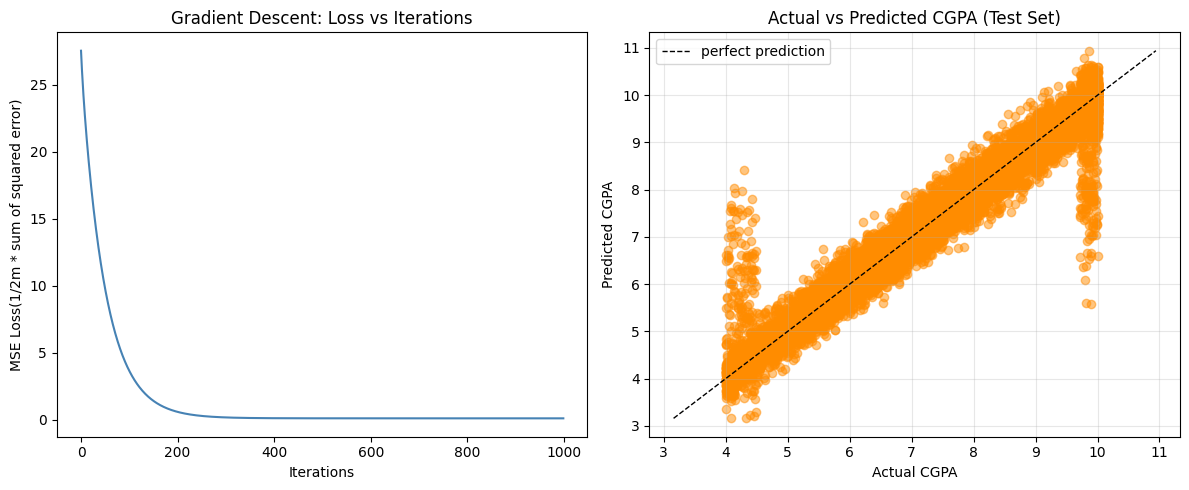

In [ ]:
import matplotlib.pyplot as plt

fig,axes = plt.subplots(1,2, figsize=(12,5))
axes[0].plot(range(len(losses)),losses,color="steelblue")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("MSE Loss(1/2m * sum of squared error)")
axes[0].set_title("Gradient Descent: Loss vs Iterations")

axes[1].scatter(y_test, y_pred, color="darkorange", alpha=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[1].plot(lims, lims, color="black",linestyle="--",linewidth=1,label ="perfect prediction")
axes[1].set_xlabel("Actual CGPA")
axes[1].set_ylabel("Predicted CGPA")
axes[1].set_title("Actual vs Predicted CGPA (Test Set)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("gradient_descent_plots.png",dpi=150)
print("\nSaved plots to gradient_descent_plots.png")
plt.show()